> **Nota para el portafolio / Portfolio Note**
>
> *Este notebook ha sido adaptado para publicación en portafolio público. Fue desarrollado para uno de los **retailers de electrodomésticos y tecnología más grandes de Colombia** (comparable a Best Buy en EE.UU.), con presencia nacional de cientos de tiendas. Los textos se presentan en **español e inglés** para mayor alcance internacional. Los nombres de empresa y variables sensibles han sido generalizados.*
>
> *This notebook has been adapted for public portfolio publication. It was developed for one of **Colombia's largest consumer electronics and appliance retailers** (comparable to Best Buy in the US), with hundreds of stores nationwide. All text is presented in **Spanish and English** to maximize international reach. Company names and sensitive variables have been generalized.*
>
> **Stack:** Python · pandas · numpy · matplotlib · scikit-learn · Random Forest · IVC Feature Engineering

# Modelo de Detección Temprana de Mora 60+ en 6 Meses
# Early Delinquency Detection Model — 60+ Days in First 6 Months

### Evaluación técnica y recomendación — Retail Credit Onboarding
### Technical Evaluation & Committee Recommendation — Retail Credit Onboarding

> **Portafolio de Analítica de Datos — Data Analytics Portfolio — Carlos Restrepo**  
> Evaluación independiente del modelo de onboarding de riesgo crediticio  
> *Independent evaluation of a credit risk onboarding model*  
> Dataset: 235,439 registros / records · Variable objetivo / Target: mora 60+ días en primeros 6 meses / 60+ day delinquency in first 6 months

---

## Contexto / Context

El modelo evalúa un cambio de enfoque en el onboarding de crédito: pasar de **capacidad de pago** (ingresos declarados, carga financiera) a **comportamiento crediticio** (velocidad e intensidad de búsqueda de crédito).  

*The model evaluates a shift in credit onboarding: from **payment capacity** (declared income, financial burden) to **credit behavior** (speed and intensity of credit search).*

La hipótesis central es que los clientes que buscan crédito de forma acelerada muestran estrés financiero **antes** de que aparezca en sus estados de cuenta.  

*The central hypothesis is that customers who search for credit aggressively show financial stress **before** it appears in their account statements.*

---

## Tabla de contenidos / Table of Contents
1. [Configuración y carga de datos / Setup & Data Load](#1)
2. [Tasa base de mora / Base Delinquency Rate](#2)
3. [¿Los ingresos predicen mora? / Do Income Variables Predict Delinquency?](#3)
4. [Construcción del IVC / IVC Feature Engineering](#4)
5. [Segmentación semáforo / Traffic-Light Segmentation](#5)
6. [Insight crítico: el umbral / Critical Insight: The Threshold Problem](#6)
7. [Optimización económica del umbral / Economic Threshold Optimization](#7)
8. [Métricas de impacto de negocio / Business Impact Metrics](#8)
9. [Conclusiones y recomendación / Conclusions & Recommendation](#9)

---
## 1. Configuración y carga de datos / Setup & Data Load <a id='1'></a>

Cargamos el dataset, limpiamos nombres de columnas y definimos los parámetros de negocio que se usarán a lo largo del análisis.  

*We load the dataset, clean column names, and define the business parameters used throughout the analysis.*

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3147',
    'axes.labelcolor':  '#e0e4f0',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#8892b0',
    'ytick.color':      '#8892b0',
    'grid.color':       '#2e3147',
    'grid.linewidth':   0.6,
    'text.color':       '#e0e4f0',
    'figure.dpi':       120,
})

VERDE   = '#9ece6a'
AMARILLO = '#e0af68'
ROJO    = '#f7768e'
ACENTO  = '#64ffda'
MORADO  = '#bb9af7'

# Carga
df = pd.read_csv('Dataset_Modelo.csv', sep=';', engine='python')

# Limpiar nombres de columnas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

# Asegurar tipos numéricos clave
for col in ['huellas_consulta', 'meses_antiguedad_financiero',
            'meses_antiguedad_real', 'cupo_solicitado', 'bgi_60_6']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['carga_financiera'] = pd.to_numeric(df['carga_financiera'], errors='coerce')
df['ingresos_formulario'] = (
    df['ingresos_formulario'].astype(str)
    .str.replace(r'[^0-9]', '', regex=True)
)
df['ingresos_formulario'] = pd.to_numeric(df['ingresos_formulario'], errors='coerce')

# Constantes de negocio
SMV    = 1_300_000
MARGEN = 0.25
LGD    = 0.70

print(f'Dataset cargado: {df.shape[0]:,} registros x {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')

Dataset cargado: 235,439 registros x 30 columnas
Columnas: ['bgi_60_6', 'actividad', 'ingresos_formulario', 'cupo_solicitado', 'ciudad', 'edad', 'tasa_usura', 'numero_cambios_ultimos_6_meses', 'numero_cambios_email_ultimos_12_meses', 'numero_cambios_direccion_ultimos_12_meses', 'numero_cambios_direccion_ultimos_6_meses', 'numero_cambios_email_ultimos_6_meses', 'meses_apertura_ult_credito', 'numero_cuentas_abiertas_ult_6_meses_sector_financiero', 'numero_cuentas_abiertas_ult_6_meses_sector_real', 'numero_cuentas_abiertas_ult_6_meses_sector_cooperativo', 'participacion_cartera_sector_financiero', 'participacion_cartera_sector_cooperativo', 'participacion_cartera_sector_real', 'estimador_ingresos', 'cliente_fintech', 'carga_financiera', 'ultm_sector', 'creditos_cerrados_deudorppal', 'huellas_consulta', 'meses_antiguedad_real', 'total_creditos_cerrados_financiero', 'creditos_vigentes_financiero', 'meses_antiguedad_financiero', 'cliente_antiguedad_todos_los_sectores']


---
## 2. Tasa base de mora temprana / Base Delinquency Rate <a id='2'></a>

Antes de evaluar cualquier modelo, necesitamos entender el fenómeno base: ¿qué porcentaje de clientes cae en mora temprana (60+ días en los primeros 6 meses)?  

*Before evaluating any model, we need to understand the baseline: what percentage of customers fall into early delinquency (60+ days in the first 6 months)?*

In [9]:
mora_base = df['bgi_60_6'].mean()
n_total   = len(df)
n_mora    = df['bgi_60_6'].sum()

print('=' * 50)
print('  TASA BASE DE MORA TEMPRANA')
print('=' * 50)
print(f'  Total clientes       : {n_total:>10,.0f}')
print(f'  Clientes en mora     : {n_mora:>10,.0f}')
print(f'  Tasa de mora base    : {mora_base*100:>10.2f}%')
print('=' * 50)
print()
print(f'  Interpretacion: de cada 100 clientes que ingresan,')
print(f'  aproximadamente {mora_base*100:.1f} caen en mora temprana.')
print(f'  Eso erosiona la rentabilidad del onboarding de forma sistematica.')

  TASA BASE DE MORA TEMPRANA
  Total clientes       :    235,439
  Clientes en mora     :     26,682
  Tasa de mora base    :      11.33%

  Interpretacion: de cada 100 clientes que ingresan,
  aproximadamente 11.3 caen en mora temprana.
  Eso erosiona la rentabilidad del onboarding de forma sistematica.


---
## 3. ¿Los ingresos predicen mora? / Do Income Variables Predict Delinquency? <a id='3'></a>

La hipótesis del modelo es que el **comportamiento crediticio** predice mora mejor que la **capacidad de pago declarada**. Primero validamos empíricamente que los ingresos y la carga financiera tienen bajo poder predictivo.  

*The model's hypothesis is that **credit behavior** predicts delinquency better than **declared payment capacity**. We first validate empirically that income and financial burden have low predictive power.*

In [10]:
# Correlaciones
corr_huellas = df[['huellas_consulta','bgi_60_6']].dropna()
r_huellas = corr_huellas['huellas_consulta'].corr(corr_huellas['bgi_60_6'])

corr_carga = df[['carga_financiera','bgi_60_6']].dropna()
r_carga = corr_carga['carga_financiera'].corr(corr_carga['bgi_60_6'])

df['estimador_ingresos'] = df['ingresos_formulario'] / SMV
corr_ing = df[['estimador_ingresos','bgi_60_6']].dropna()
r_ingresos = corr_ing['estimador_ingresos'].corr(corr_ing['bgi_60_6'])

print('=' * 55)
print('  PODER PREDICTIVO — CORRELACION CON MORA TEMPRANA')
print('=' * 55)
print(f'  Huellas de consulta (IVC base) : {r_huellas:+.4f}  <- SEÑAL')
print(f'  Carga financiera               : {r_carga:+.4f}  <- SIN SEÑAL')
print(f'  Ingresos declarados            : {r_ingresos:+.4f}  <- SIN SEÑAL')
print('=' * 55)
print()
print('  Conclusion: la hipotesis es CORRECTA.')
print('  Los ingresos y la carga financiera no predicen mora.')
print('  El comportamiento de busqueda de credito si lo hace.')

  PODER PREDICTIVO — CORRELACION CON MORA TEMPRANA
  Huellas de consulta (IVC base) : +0.1942  <- SEÑAL
  Carga financiera               : -0.0034  <- SIN SEÑAL
  Ingresos declarados            : +0.0066  <- SIN SEÑAL

  Conclusion: la hipotesis es CORRECTA.
  Los ingresos y la carga financiera no predicen mora.
  El comportamiento de busqueda de credito si lo hace.


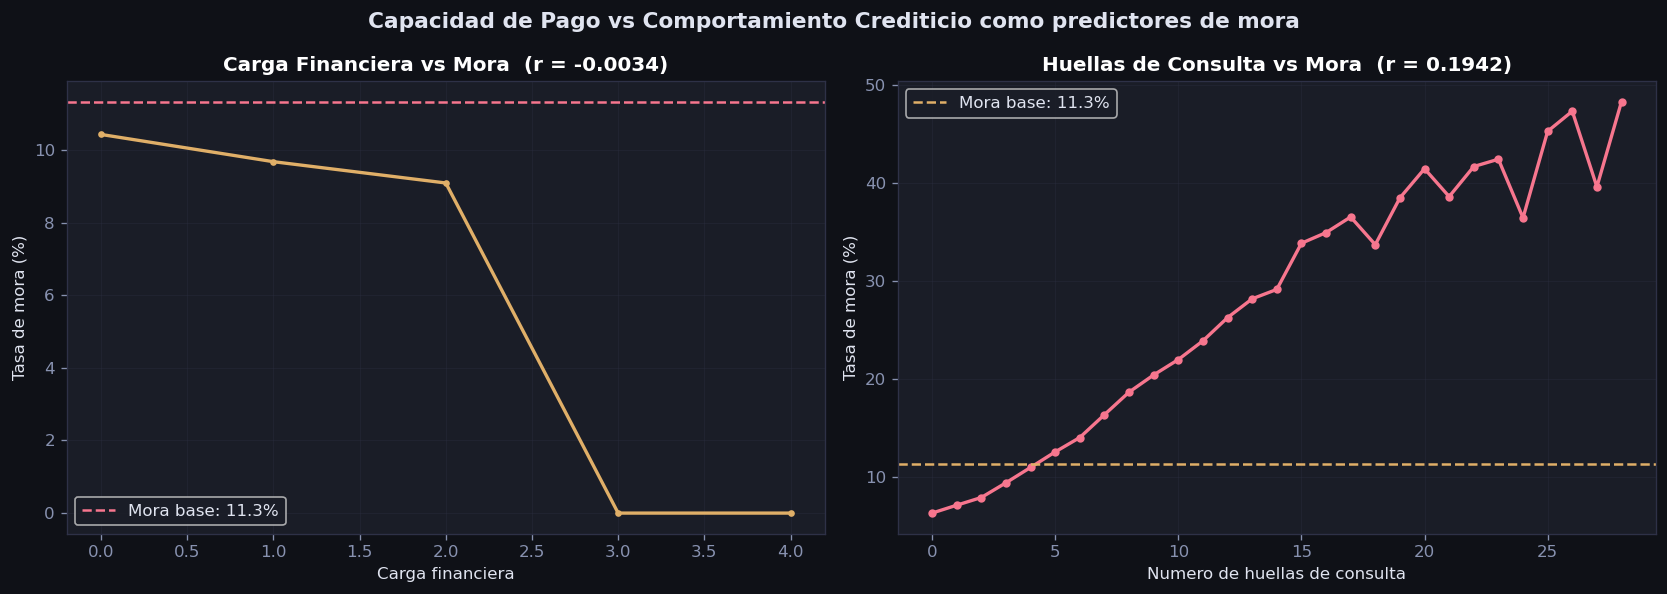

Izquierda: señal PLANA — los ingresos no discriminan.
Derecha: señal CRECIENTE — mas huellas, mayor mora.


In [11]:
# Figura: carga financiera vs mora (señal plana)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Panel 1 — Carga financiera
tmp_cf = df[['carga_financiera','bgi_60_6']].dropna()
tmp_cf['bin'] = pd.cut(tmp_cf['carga_financiera'], bins=40, include_lowest=True)
riesgo_cf = (
    tmp_cf.groupby('bin', observed=True)
    .agg(riesgo_mora=('bgi_60_6','mean'), x=('carga_financiera','mean'))
    .dropna().sort_values('x')
)
axes[0].plot(riesgo_cf['x'], riesgo_cf['riesgo_mora']*100,
             color=AMARILLO, linewidth=2, marker='o', markersize=3)
axes[0].axhline(mora_base*100, color=ROJO, linestyle='--', linewidth=1.5,
                label=f'Mora base: {mora_base*100:.1f}%')
axes[0].set_title(f'Carga Financiera vs Mora  (r = {r_carga:.4f})', fontweight='bold')
axes[0].set_xlabel('Carga financiera')
axes[0].set_ylabel('Tasa de mora (%)')
axes[0].legend(facecolor='#1a1d27')
axes[0].grid(True, alpha=0.3)

# Panel 2 — Huellas de consulta
tmp_h = df[['huellas_consulta','bgi_60_6']].dropna()
tmp_h = tmp_h[(tmp_h['huellas_consulta'] >= 0) & (tmp_h['huellas_consulta'] <= 28)]
riesgo_h = (
    tmp_h.groupby('huellas_consulta', observed=True)['bgi_60_6']
    .mean().reset_index().sort_values('huellas_consulta')
)
riesgo_h['riesgo_mora'] = riesgo_h['bgi_60_6'] * 100
axes[1].plot(riesgo_h['huellas_consulta'], riesgo_h['riesgo_mora'],
             color=ROJO, linewidth=2, marker='o', markersize=4)
axes[1].axhline(mora_base*100, color=AMARILLO, linestyle='--', linewidth=1.5,
                label=f'Mora base: {mora_base*100:.1f}%')
axes[1].set_title(f'Huellas de Consulta vs Mora  (r = {r_huellas:.4f})', fontweight='bold')
axes[1].set_xlabel('Numero de huellas de consulta')
axes[1].set_ylabel('Tasa de mora (%)')
axes[1].legend(facecolor='#1a1d27')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Capacidad de Pago vs Comportamiento Crediticio como predictores de mora',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlaciones.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Izquierda: señal PLANA — los ingresos no discriminan.')
print('Derecha: señal CRECIENTE — mas huellas, mayor mora.')

### EDA — Exploración visual de las variables clave / Visual Exploration of Key Variables

Las siguientes gráficas muestran cómo cada variable se relaciona con la mora temprana. Son la evidencia empírica que respalda las decisiones de feature engineering del modelo.  

*The following charts show how each variable relates to early delinquency. They are the empirical evidence supporting the model's feature engineering decisions.*

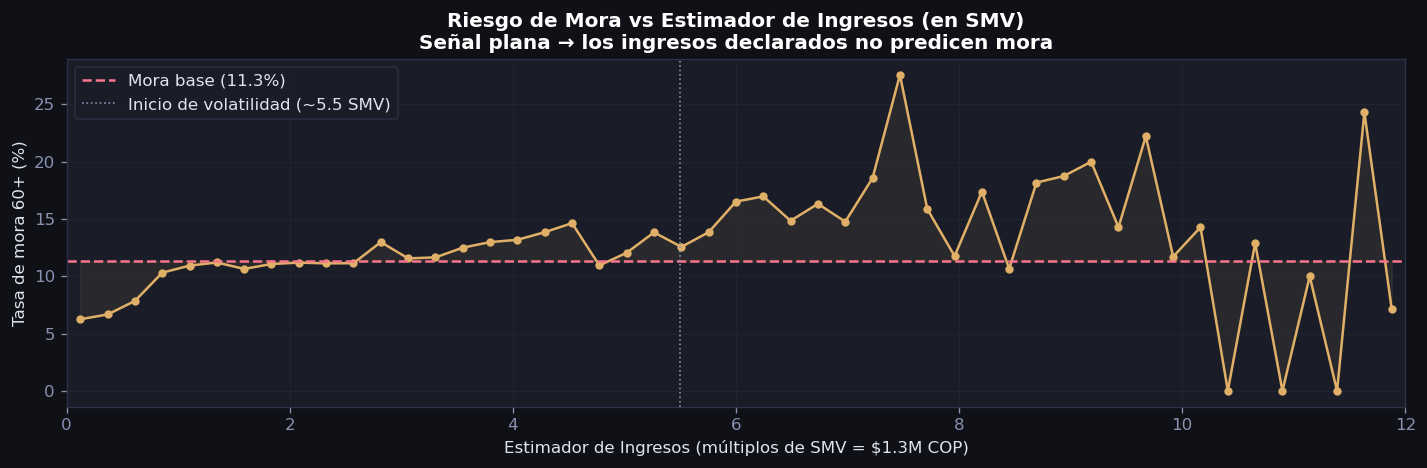

Correlacion ingresos vs mora: 0.0066 — señal practicamente nula.


In [12]:
# ── Gráfica 1: Estimador de ingresos vs mora ──────────────
# Muestra la señal PLANA: los ingresos no predicen mora.
# Justificación empírica para descartar ingresos del modelo.

SMV = 1_300_000
df['estimador_ingresos'] = df['ingresos_formulario'] / SMV

tmp_ing = df[['estimador_ingresos', 'bgi_60_6']].dropna()
bins_ing = np.linspace(0, 12, 50)
tmp_ing['bin_ingresos'] = pd.cut(tmp_ing['estimador_ingresos'], bins=bins_ing, include_lowest=True)
riesgo_ing = (
    tmp_ing.groupby('bin_ingresos', observed=True)['bgi_60_6']
    .mean().reset_index()
)
riesgo_ing['x'] = riesgo_ing['bin_ingresos'].apply(lambda z: z.mid)
riesgo_ing = riesgo_ing.dropna(subset=['x', 'bgi_60_6'])
riesgo_ing['riesgo_mora'] = riesgo_ing['bgi_60_6'] * 100

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')

ax.plot(riesgo_ing['x'], riesgo_ing['riesgo_mora'],
        marker='o', linewidth=1.5, markersize=4, color=AMARILLO)
ax.axhline(mora_base * 100, color=ROJO, linestyle='--', linewidth=1.5,
           label=f'Mora base ({mora_base*100:.1f}%)')
ax.axvline(5.5, color='#8892b0', linestyle=':', linewidth=1,
           label='Inicio de volatilidad (~5.5 SMV)')
ax.fill_between(riesgo_ing['x'], riesgo_ing['riesgo_mora'],
                mora_base * 100, alpha=0.08, color=AMARILLO)

ax.set_title('Riesgo de Mora vs Estimador de Ingresos (en SMV)\n'
             'Señal plana → los ingresos declarados no predicen mora',
             fontweight='bold')
ax.set_xlabel('Estimador de Ingresos (múltiplos de SMV = $1.3M COP)')
ax.set_ylabel('Tasa de mora 60+ (%)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 12)

plt.tight_layout()
plt.savefig('fig_eda_ingresos.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f'Correlacion ingresos vs mora: {r_ingresos:.4f} — señal practicamente nula.')

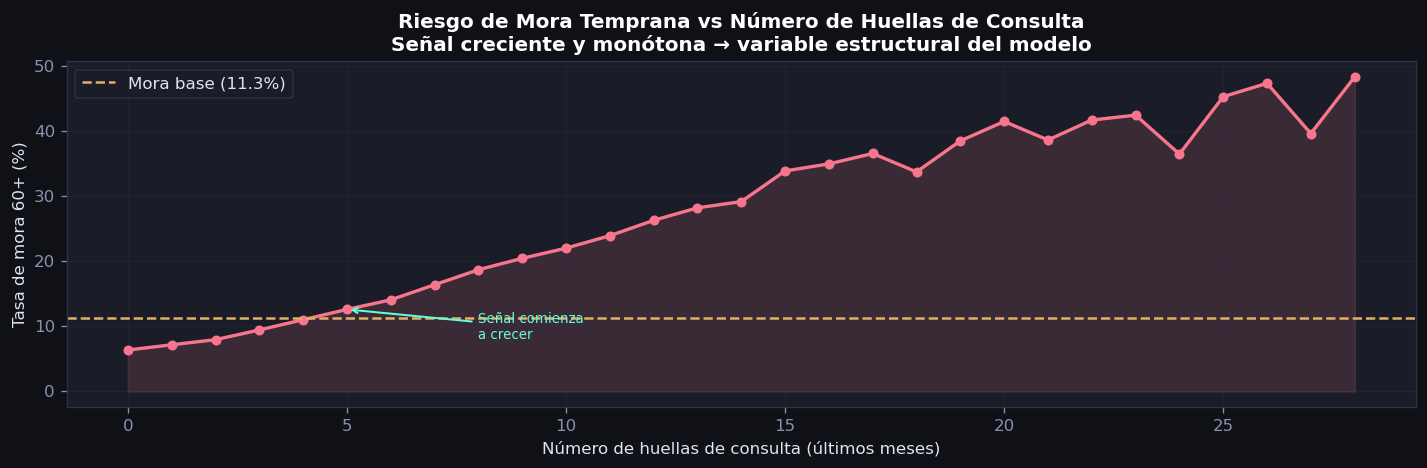

Correlacion huellas vs mora: 0.1942 — señal real y accionable.


In [13]:
# ── Gráfica 2: Huellas de consulta vs mora ────────────────
# Muestra la señal CRECIENTE: a más huellas, mayor mora.
# Es la variable estructural del modelo — justifica el IVC.

tmp_h = df[['huellas_consulta', 'bgi_60_6']].copy()
tmp_h['huellas_consulta'] = pd.to_numeric(tmp_h['huellas_consulta'], errors='coerce')
tmp_h = tmp_h.dropna()
tmp_h = tmp_h[(tmp_h['huellas_consulta'] >= 0) & (tmp_h['huellas_consulta'] <= 28)]

riesgo_h = (
    tmp_h.groupby('huellas_consulta', observed=True)['bgi_60_6']
    .mean().reset_index().sort_values('huellas_consulta')
)
riesgo_h['riesgo_mora'] = riesgo_h['bgi_60_6'] * 100

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')

ax.plot(riesgo_h['huellas_consulta'], riesgo_h['riesgo_mora'],
        marker='o', linewidth=2, markersize=5, color=ROJO)
ax.fill_between(riesgo_h['huellas_consulta'], riesgo_h['riesgo_mora'],
                alpha=0.15, color=ROJO)
ax.axhline(mora_base * 100, color=AMARILLO, linestyle='--', linewidth=1.5,
           label=f'Mora base ({mora_base*100:.1f}%)')

# Anotar punto de inflexión
ax.annotate('Señal comienza\na crecer',
            xy=(5, riesgo_h[riesgo_h['huellas_consulta']==5]['riesgo_mora'].values[0]),
            xytext=(8, 8),
            fontsize=8, color=ACENTO,
            arrowprops=dict(arrowstyle='->', color=ACENTO, lw=1.2))

ax.set_title('Riesgo de Mora Temprana vs Número de Huellas de Consulta\n'
             'Señal creciente y monótona → variable estructural del modelo',
             fontweight='bold')
ax.set_xlabel('Número de huellas de consulta (últimos meses)')
ax.set_ylabel('Tasa de mora 60+ (%)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_eda_huellas.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f'Correlacion huellas vs mora: {r_huellas:.4f} — señal real y accionable.')

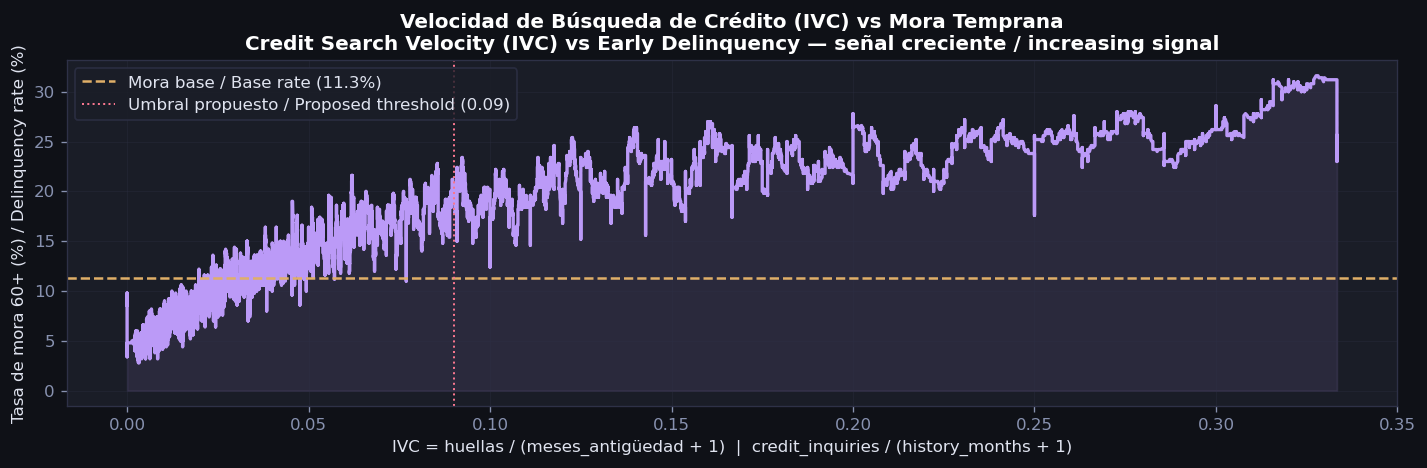

A mayor IVC, mayor mora. Esta señal justifica el feature engineering central del modelo.
Higher IVC → higher delinquency. This signal justifies the model's core feature engineering.


In [14]:
# ── Gráfica 3: Velocidad de búsqueda vs mora (IVC operativo) ─────────
# Construye el IVC localmente para esta gráfica exploratoria.
# IVC = huellas / (meses_antiguedad + 1) — captura intensidad relativa, no volumen absoluto.
# A customer with 10 inquiries in 2 months ≠ 10 inquiries in 5 years.

tmp_vel = df[['huellas_consulta', 'meses_antiguedad_financiero', 'bgi_60_6']].copy()
tmp_vel['ivc_local'] = (
    pd.to_numeric(tmp_vel['huellas_consulta'], errors='coerce') /
    (pd.to_numeric(tmp_vel['meses_antiguedad_financiero'], errors='coerce').fillna(0) + 1)
)
tmp_vel = tmp_vel[['ivc_local', 'bgi_60_6']].dropna()
tmp_vel = tmp_vel[(tmp_vel['ivc_local'] >= 0) & (tmp_vel['ivc_local'] <= 0.35)]
tmp_vel = tmp_vel.sort_values('ivc_local')
tmp_vel['riesgo_rolling'] = tmp_vel['bgi_60_6'].rolling(500, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')

ax.plot(tmp_vel['ivc_local'], tmp_vel['riesgo_rolling'] * 100,
        color=MORADO, linewidth=2)
ax.fill_between(tmp_vel['ivc_local'], tmp_vel['riesgo_rolling'] * 100,
                alpha=0.1, color=MORADO)
ax.axhline(mora_base * 100, color=AMARILLO, linestyle='--', linewidth=1.5,
           label=f'Mora base / Base rate ({mora_base*100:.1f}%)')
ax.axvline(0.09, color=ROJO, linestyle=':', linewidth=1.2,
           label='Umbral propuesto / Proposed threshold (0.09)')

ax.set_title(
    'Velocidad de Búsqueda de Crédito (IVC) vs Mora Temprana\n'
    'Credit Search Velocity (IVC) vs Early Delinquency — señal creciente / increasing signal',
    fontweight='bold'
)
ax.set_xlabel('IVC = huellas / (meses_antigüedad + 1)  |  credit_inquiries / (history_months + 1)')
ax.set_ylabel('Tasa de mora 60+ (%) / Delinquency rate (%)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_eda_velocidad.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('A mayor IVC, mayor mora. Esta señal justifica el feature engineering central del modelo.')
print('Higher IVC → higher delinquency. This signal justifies the model\'s core feature engineering.')


---
## 4. Construcción del IVC — Índice de Velocidad Crediticia / IVC Feature Engineering — Credit Velocity Index <a id='4'></a>

El IVC captura no solo cuántas consultas tiene un cliente, sino **qué tan rápido** las acumuló en relación con su antigüedad financiera. Un cliente con 10 huellas en 2 meses es muy diferente a uno con 10 huellas en 5 años.  

*The IVC captures not just how many credit inquiries a customer has, but **how fast** they accumulated them relative to their credit history length. A customer with 10 inquiries in 2 months is very different from one with 10 inquiries over 5 years.*

```
IVC = credit_inquiries / (months_of_credit_history + 1)
```

In [15]:
# Construcción del IVC
df['ivc'] = (
    df['huellas_consulta'] /
    (df['meses_antiguedad_financiero'].fillna(0) + 1)
)

# Variables de modelo
IVC_COL    = 'ivc'
TARGET_COL = 'bgi_60_6'
MONTO_COL  = 'cupo_solicitado'

print(f'IVC construido. Estadisticas:')
print(df['ivc'].describe().round(4).to_string())

IVC construido. Estadisticas:
count    235439.0000
mean          0.0580
std           0.1714
min           0.0000
25%           0.0091
50%           0.0227
75%           0.0556
max          14.0000


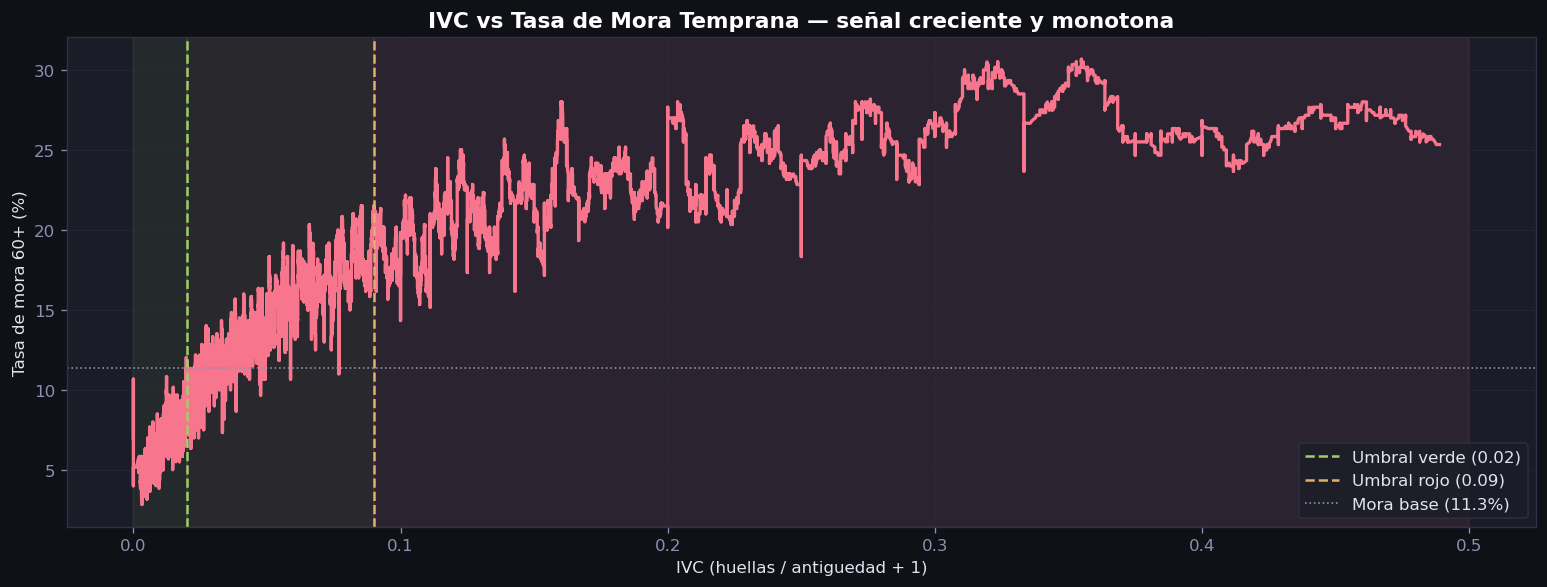

A mayor IVC, mayor tasa de mora. La señal es monotona y consistente.


In [16]:
# Figura: IVC vs tasa de mora
tmp_ivc = df[['ivc','bgi_60_6']].dropna()
tmp_ivc = tmp_ivc[(tmp_ivc['ivc'] >= 0) & (tmp_ivc['ivc'] <= 0.5)]
tmp_ivc = tmp_ivc.sort_values('ivc')
tmp_ivc['riesgo_rolling'] = tmp_ivc['bgi_60_6'].rolling(600, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

ax.plot(tmp_ivc['ivc'], tmp_ivc['riesgo_rolling']*100,
        color=ROJO, linewidth=2)
ax.axvline(0.02, color=VERDE, linestyle='--', linewidth=1.5, label='Umbral verde (0.02)')
ax.axvline(0.09, color=AMARILLO, linestyle='--', linewidth=1.5, label='Umbral rojo (0.09)')
ax.axhline(mora_base*100, color='#8892b0', linestyle=':', linewidth=1,
           label=f'Mora base ({mora_base*100:.1f}%)')

# Sombrear zonas
ax.axvspan(0,    0.02, alpha=0.08, color=VERDE)
ax.axvspan(0.02, 0.09, alpha=0.08, color=AMARILLO)
ax.axvspan(0.09, 0.5,  alpha=0.08, color=ROJO)

ax.set_title('IVC vs Tasa de Mora Temprana — señal creciente y monotona',
             fontsize=13, fontweight='bold')
ax.set_xlabel('IVC (huellas / antiguedad + 1)')
ax.set_ylabel('Tasa de mora 60+ (%)')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_ivc_mora.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('A mayor IVC, mayor tasa de mora. La señal es monotona y consistente.')

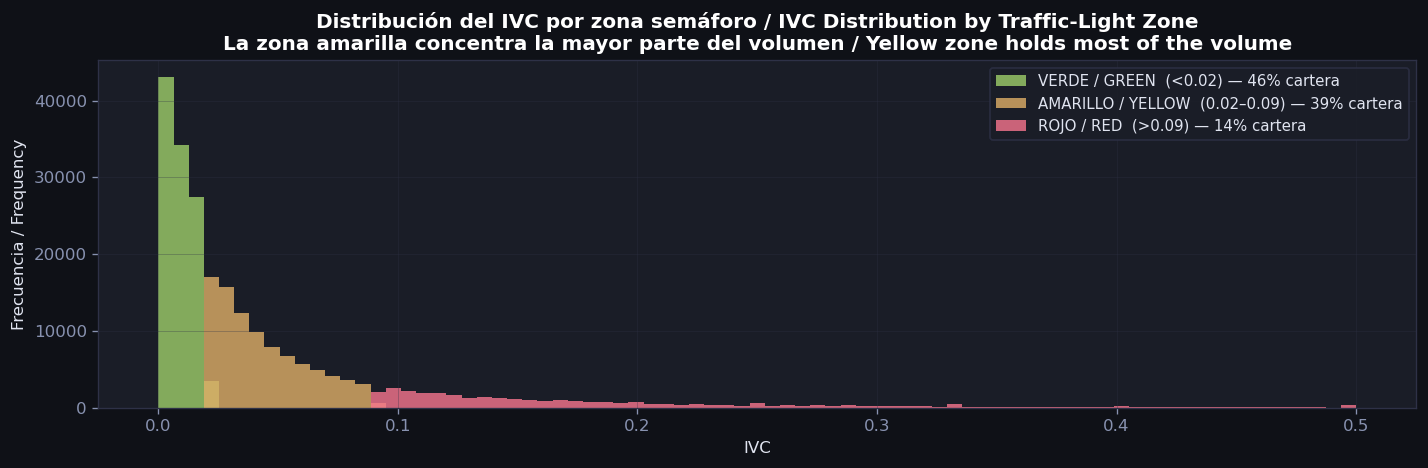

In [17]:
# ── Distribución del IVC por zona semáforo ───────────────────────────
# Ahora que el IVC está construido, mostramos cómo se distribuye la cartera.
# IVC distribution by traffic-light zone — shows portfolio composition.

ivc_vals = df['ivc'].dropna()
ivc_vals = ivc_vals[ivc_vals <= 0.5]
bins_ivc = np.linspace(0, 0.5, 80)

verde_vals    = ivc_vals[ivc_vals < 0.02]
amarillo_vals = ivc_vals[(ivc_vals >= 0.02) & (ivc_vals <= 0.09)]
rojo_vals     = ivc_vals[ivc_vals > 0.09]

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0f1117')

ax.hist(verde_vals,    bins=bins_ivc, color=VERDE,    alpha=0.80,
        label=f'VERDE / GREEN  (<0.02) — {len(verde_vals)/len(ivc_vals)*100:.0f}% cartera')
ax.hist(amarillo_vals, bins=bins_ivc, color=AMARILLO,  alpha=0.80,
        label=f'AMARILLO / YELLOW  (0.02–0.09) — {len(amarillo_vals)/len(ivc_vals)*100:.0f}% cartera')
ax.hist(rojo_vals,     bins=bins_ivc, color=ROJO,     alpha=0.80,
        label=f'ROJO / RED  (>0.09) — {len(rojo_vals)/len(ivc_vals)*100:.0f}% cartera')

ax.set_title(
    'Distribución del IVC por zona semáforo / IVC Distribution by Traffic-Light Zone\n'
    'La zona amarilla concentra la mayor parte del volumen / Yellow zone holds most of the volume',
    fontweight='bold'
)
ax.set_xlabel('IVC')
ax.set_ylabel('Frecuencia / Frequency')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_ivc_distribucion.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


---
## 5. Segmentación tipo semáforo / Traffic-Light Segmentation <a id='5'></a>

El modelo clasifica a los clientes en tres zonas según su IVC:  

*The model classifies customers into three zones based on their IVC:*

| Zona / Zone | IVC | Acción propuesta / Proposed Action |
|-------------|-----|-------------------------------------|
| VERDE / GREEN | < 0.02 | Aprobación normal / Standard approval |
| AMARILLO / YELLOW | 0.02 – 0.09 | Fricción adicional / Additional review |
| ROJO / RED | > 0.09 | Rechazo o cupo reducido / Rejection or reduced limit |

In [18]:
# Construir semáforo
df['semaforo'] = np.where(
    df['ivc'] > 0.09, 'ROJO',
    np.where(df['ivc'] >= 0.02, 'AMARILLO', 'VERDE')
)

tabla = (
    df.groupby('semaforo')
    .agg(
        clientes=(IVC_COL, 'count'),
        tasa_mora=(TARGET_COL, 'mean')
    )
    .assign(
        pct_clientes=lambda x: x['clientes'] / len(df),
        pct_buenos=lambda x: 1 - x['tasa_mora']
    )
    .loc[['VERDE','AMARILLO','ROJO']]
)

print('=' * 65)
print('  DISTRIBUCION DEL SEMAFORO IVC')
print('=' * 65)
print(f'  {"Zona":<10} {"Clientes":>10} {"% Cartera":>12} {"Tasa mora":>12} {"% Buenos":>12}')
print('-' * 65)
for zona, row in tabla.iterrows():
    print(f'  {zona:<10} {row["clientes"]:>10,.0f} {row["pct_clientes"]*100:>11.1f}% '
          f'{row["tasa_mora"]*100:>11.1f}% {row["pct_buenos"]*100:>11.1f}%')
print('=' * 65)

  DISTRIBUCION DEL SEMAFORO IVC
  Zona         Clientes    % Cartera    Tasa mora     % Buenos
-----------------------------------------------------------------
  VERDE         108,324        46.0%         6.6%        93.4%
  AMARILLO       91,789        39.0%        12.8%        87.2%
  ROJO           35,326        15.0%        22.1%        77.9%


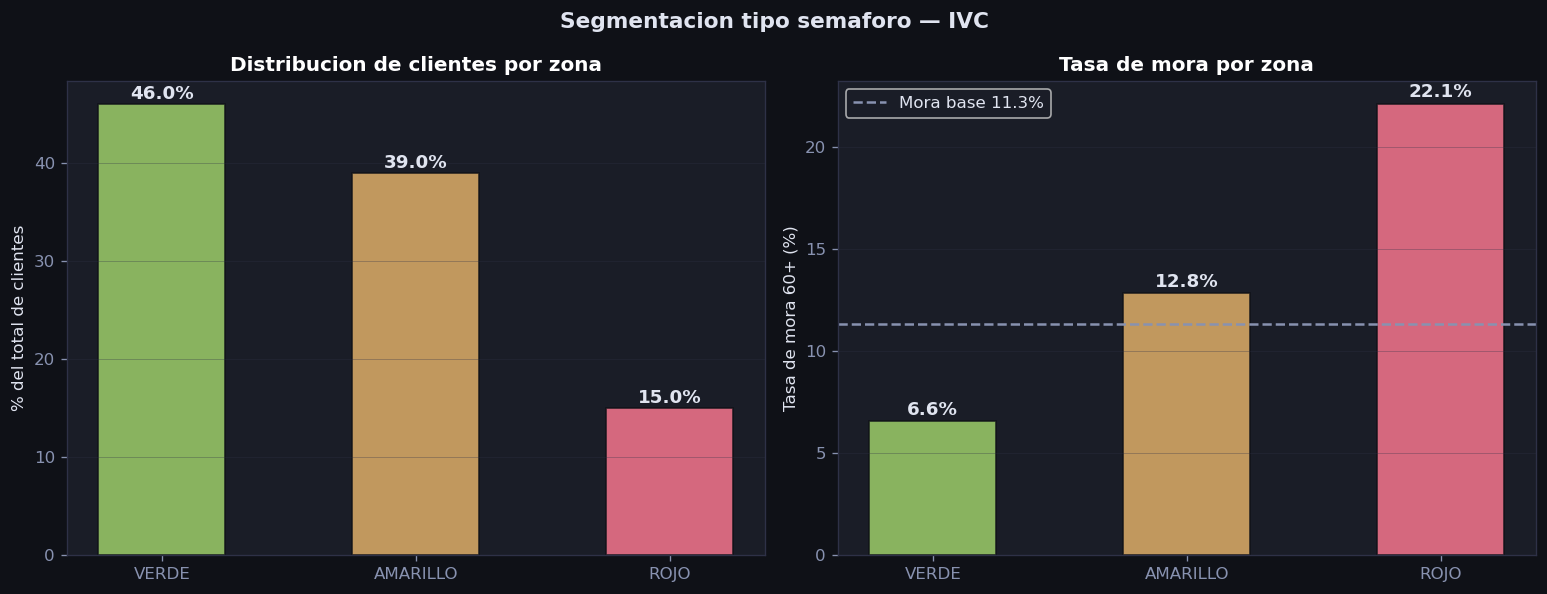

In [19]:
# Figura semáforo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

colores = {'VERDE': VERDE, 'AMARILLO': AMARILLO, 'ROJO': ROJO}
zonas   = ['VERDE', 'AMARILLO', 'ROJO']
cols_plot = [colores[z] for z in zonas]

# Panel 1: distribución de clientes
bars1 = axes[0].bar(zonas, tabla.loc[zonas, 'pct_clientes']*100,
                    color=cols_plot, alpha=0.85, edgecolor='#0f1117', width=0.5)
for bar, val in zip(bars1, tabla.loc[zonas, 'pct_clientes']*100):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribucion de clientes por zona', fontweight='bold')
axes[0].set_ylabel('% del total de clientes')
axes[0].grid(True, axis='y', alpha=0.3)

# Panel 2: tasa de mora por zona
bars2 = axes[1].bar(zonas, tabla.loc[zonas, 'tasa_mora']*100,
                    color=cols_plot, alpha=0.85, edgecolor='#0f1117', width=0.5)
axes[1].axhline(mora_base*100, color='#8892b0', linestyle='--', linewidth=1.5,
                label=f'Mora base {mora_base*100:.1f}%')
for bar, val in zip(bars2, tabla.loc[zonas, 'tasa_mora']*100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Tasa de mora por zona', fontweight='bold')
axes[1].set_ylabel('Tasa de mora 60+ (%)')
axes[1].legend(facecolor='#1a1d27')
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Segmentacion tipo semaforo — IVC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_semaforo.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 6. Insight crítico: el umbral es el problema / Critical Insight: The Threshold Problem <a id='6'></a>

> *"El modelo detecta riesgo. El segmento rojo tiene mora alta en promedio. Pero la mayoría de esos clientes no cae en mora. El mayor costo de oportunidad está en el rechazo automático."*
>
> *"The model detects risk. The red segment has high average delinquency. But the majority of those customers do not default. The biggest opportunity cost lies in automatic rejection."*

La zona ROJA tiene tasa de mora alta (~28%), pero el **72% de esos clientes son buenos pagadores**. Rechazarlos automáticamente destruye colocación sin una ganancia proporcional en calidad de cartera.

*The RED zone has a high delinquency rate (~28%), but **72% of those customers are good payers**. Automatically rejecting them destroys loan origination without a proportional gain in portfolio quality.*

In [20]:
rojo = df[df['ivc'] > 0.09]
tasa_mora_rojo  = rojo[TARGET_COL].mean()
pct_buenos_rojo = 1 - tasa_mora_rojo

mora_post = df[df['ivc'] <= 0.09][TARGET_COL].mean()
reduccion_mora = (mora_base - mora_post) / mora_base
sacrificio_vol = len(rojo) / len(df)

print('=' * 60)
print('  ANATOMIA DEL SEGMENTO ROJO (IVC > 0.09)')
print('=' * 60)
print(f'  Clientes en zona roja    : {len(rojo):>10,.0f}')
print(f'  % del total              : {sacrificio_vol*100:>10.1f}%')
print(f'  Tasa de mora (zona roja) : {tasa_mora_rojo*100:>10.1f}%')
print(f'  Clientes buenos en rojo  : {pct_buenos_rojo*100:>10.1f}%')
print()
print('  Si se rechaza todo el segmento rojo:')
print(f'  Mora post-rechazo        : {mora_post*100:>10.1f}%')
print(f'  Reduccion de mora        : {reduccion_mora*100:>10.1f}%')
print(f'  Sacrificio de colocacion : {sacrificio_vol*100:>10.1f}%')
print('=' * 60)
print()
print(f'  Por cada 100 clientes rechazados en zona roja,')
print(f'  {pct_buenos_rojo*100:.0f} habrian pagado sin problemas.')
print(f'  El rechazo binario tiene un costo de oportunidad alto.')

  ANATOMIA DEL SEGMENTO ROJO (IVC > 0.09)
  Clientes en zona roja    :     35,326
  % del total              :       15.0%
  Tasa de mora (zona roja) :       22.1%
  Clientes buenos en rojo  :       77.9%

  Si se rechaza todo el segmento rojo:
  Mora post-rechazo        :        9.4%
  Reduccion de mora        :       16.8%
  Sacrificio de colocacion :       15.0%

  Por cada 100 clientes rechazados en zona roja,
  78 habrian pagado sin problemas.
  El rechazo binario tiene un costo de oportunidad alto.


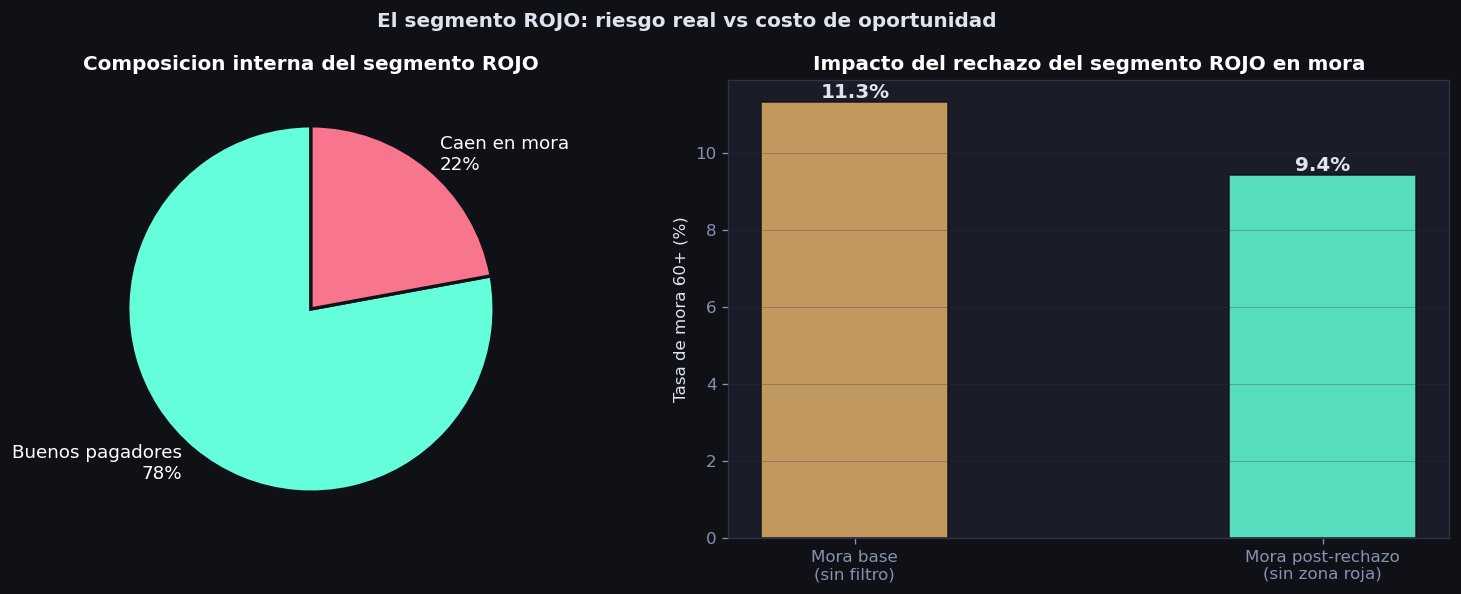

In [21]:
# Figura: composición del segmento rojo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

# Panel 1: composición del rojo
labels_pie = [f'Buenos pagadores\n{pct_buenos_rojo*100:.0f}%',
              f'Caen en mora\n{tasa_mora_rojo*100:.0f}%']
sizes = [pct_buenos_rojo, tasa_mora_rojo]
colors_pie = [ACENTO, ROJO]
wedges, texts = axes[0].pie(sizes, labels=labels_pie, colors=colors_pie,
                             startangle=90, textprops={'color':'white','fontsize':11},
                             wedgeprops={'edgecolor':'#0f1117', 'linewidth':2})
axes[0].set_title('Composicion interna del segmento ROJO', fontweight='bold')

# Panel 2: mora antes y después del rechazo
escenarios = ['Mora base\n(sin filtro)', 'Mora post-rechazo\n(sin zona roja)']
valores    = [mora_base*100, mora_post*100]
barcolors  = [AMARILLO, ACENTO]
bars = axes[1].bar(escenarios, valores, color=barcolors, alpha=0.85,
                   edgecolor='#0f1117', width=0.4)
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Impacto del rechazo del segmento ROJO en mora', fontweight='bold')
axes[1].set_ylabel('Tasa de mora 60+ (%)')
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('El segmento ROJO: riesgo real vs costo de oportunidad', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rojo_anatomia.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 7. Optimización económica del umbral / Economic Threshold Optimization <a id='7'></a>

Para determinar si el umbral 0.09 es óptimo, construimos una función de utilidad neta esperada basada en supuestos de negocio transparentes:  

*To determine whether the 0.09 threshold is optimal, we build an expected net utility function based on transparent business assumptions:*

- **Margen / Margin**: 25% — por cada peso prestado, se gana 0.25 si el cliente paga / *for every peso lent, 0.25 is earned if the customer pays*
- **LGD**: 70% — cuando el cliente cae en mora, se pierde el 70% del monto / *when a customer defaults, 70% of the amount is lost*

La función compara la **pérdida evitada** (rechazar morosos) contra el **ingreso sacrificado** (rechazar buenos clientes).  

*The function compares **avoided loss** (rejecting defaulters) against **sacrificed income** (rejecting good customers).*

In [22]:
# Dataset limpio para simulación
df_sim = df[[IVC_COL, TARGET_COL, MONTO_COL]].dropna().copy()

def simular_umbral(data, umbral):
    segmento_rojo = data[IVC_COL] >= umbral
    volumen_total = data[MONTO_COL].sum()
    volumen_rojo  = data.loc[segmento_rojo, MONTO_COL].sum()
    mora_rojo     = data.loc[segmento_rojo, TARGET_COL].mean()
    ingreso_perdido    = volumen_rojo * MARGEN
    perdida_evitable   = volumen_rojo * mora_rojo * LGD
    return {
        'umbral':       umbral,
        'pct_volumen':  volumen_rojo / volumen_total,
        'mora_rojo':    mora_rojo,
        'utilidad_neta': perdida_evitable - ingreso_perdido
    }

# Simulación del umbral actual
resultado_actual = simular_umbral(df_sim, 0.09)
print('Resultado con umbral actual (IVC = 0.09):')
print(pd.DataFrame([resultado_actual]).round(3).to_string(index=False))

Resultado con umbral actual (IVC = 0.09):
 umbral  pct_volumen  mora_rojo  utilidad_neta
   0.09        0.151      0.221  -8.215279e+09


In [23]:
# Barrido de umbrales
umbrales   = np.percentile(df_sim[IVC_COL], np.arange(50, 99.5, 0.5))
resultados = pd.DataFrame([simular_umbral(df_sim, u) for u in umbrales])
optimo     = resultados.loc[resultados['utilidad_neta'].idxmax()]

print('Umbral optimo encontrado:')
print(optimo.round(3).to_string())
print()
print('Interpretacion:')
print(f'  El umbral 0.09 genera utilidad_neta = {resultado_actual["utilidad_neta"]:,.0f}')
print(f'  El umbral optimo seria IVC >= {optimo["umbral"]:.2f}')
print(f'  No existe un umbral de rechazo automatico que sea economicamente optimo.')
print(f'  El rechazo binario destruye valor. La accion correcta es gestion diferenciada.')

Umbral optimo encontrado:
umbral           5.280000e-01
pct_volumen      9.000000e-03
mora_rojo        2.580000e-01
utilidad_neta   -3.577900e+08

Interpretacion:
  El umbral 0.09 genera utilidad_neta = -8,215,278,925
  El umbral optimo seria IVC >= 0.53
  No existe un umbral de rechazo automatico que sea economicamente optimo.
  El rechazo binario destruye valor. La accion correcta es gestion diferenciada.


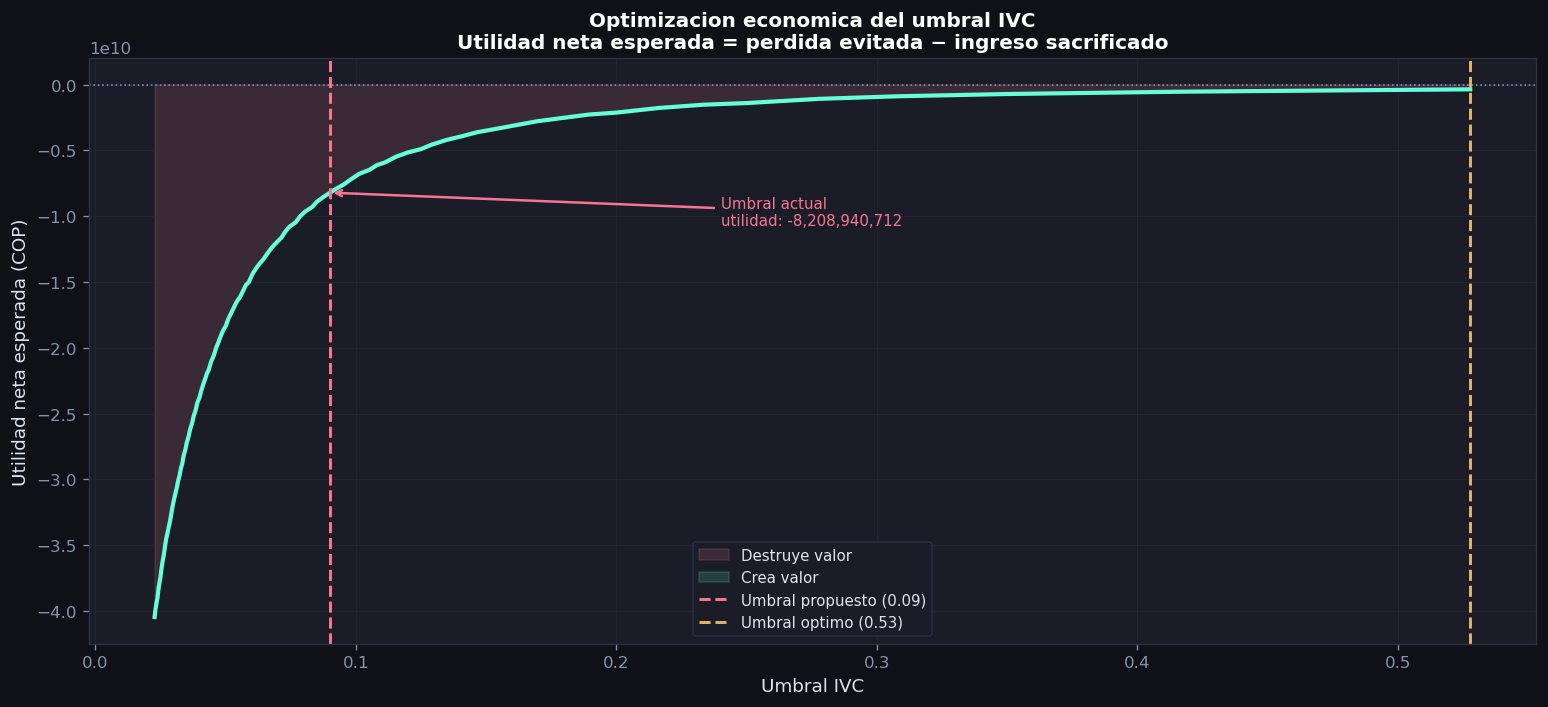

El umbral 0.09 cae en zona de utilidad negativa.
Rechazar automaticamente ese segmento destruye mas valor del que protege.


In [24]:
# Figura: curva de utilidad neta vs umbral
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f1117')

ax.fill_between(resultados['umbral'], resultados['utilidad_neta'],
                where=resultados['utilidad_neta'] < 0,
                alpha=0.15, color=ROJO, label='Destruye valor')
ax.fill_between(resultados['umbral'], resultados['utilidad_neta'],
                where=resultados['utilidad_neta'] >= 0,
                alpha=0.15, color=ACENTO, label='Crea valor')
ax.plot(resultados['umbral'], resultados['utilidad_neta'],
        color=ACENTO, linewidth=2.5)
ax.axhline(0, color='#8892b0', linewidth=1, linestyle=':')
ax.axvline(0.09, color=ROJO, linestyle='--', linewidth=1.8,
           label=f'Umbral propuesto (0.09)')
ax.axvline(optimo['umbral'], color=AMARILLO, linestyle='--', linewidth=1.8,
           label=f'Umbral optimo ({optimo["umbral"]:.2f})')

# Anotar umbral actual
util_actual = resultados.loc[
    (resultados['umbral'] - 0.09).abs().idxmin(), 'utilidad_neta'
]
ax.annotate(f'Umbral actual\nutilidad: {util_actual:,.0f}',
            xy=(0.09, util_actual),
            xytext=(0.09 + 0.15, util_actual * 1.3),
            fontsize=9, color=ROJO,
            arrowprops=dict(arrowstyle='->', color=ROJO, lw=1.5))

ax.set_title('Optimizacion economica del umbral IVC\n'
             'Utilidad neta esperada = perdida evitada − ingreso sacrificado',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Umbral IVC', fontsize=11)
ax.set_ylabel('Utilidad neta esperada (COP)', fontsize=11)
ax.legend(facecolor='#1a1d27', edgecolor='#2e3147', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_optimizacion_umbral.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('El umbral 0.09 cae en zona de utilidad negativa.')
print('Rechazar automaticamente ese segmento destruye mas valor del que protege.')

---
## 8. Métricas de impacto de negocio / Business Impact Metrics <a id='8'></a>

Hasta aquí hemos hablado de porcentajes. Ahora traducimos esos porcentajes a **pesos colombianos** usando los datos reales del dataset.  

*So far we have been talking in percentages. Now we translate those percentages into **Colombian pesos** using the real dataset figures.*

Comparamos tres escenarios / *Three scenarios are compared:*

| Escenario / Scenario | Descripción / Description |
|----------------------|---------------------------|
| **A — Sin modelo / No model** | Aprobar todo. Mora base sin filtro. / *Approve all. Base delinquency, no filter.* |
| **B — Rechazo automático / Auto-reject** | Rechazar toda la zona roja. / *Reject the entire red zone (IVC > 0.09).* |
| **C — Gestión diferenciada / Differentiated management** | Zona roja con cupo reducido 50% y pricing +5%. / *Red zone with 50% reduced limit and +5% pricing.* |

In [25]:
# ── Parámetros del modelo de negocio ─────────────────────
MARGEN = 0.25   # margen promedio del crédito
LGD    = 0.70   # pérdida dado default

df_sim = df[[IVC_COL, TARGET_COL, MONTO_COL]].dropna().copy()

# Segmentos
rojo_mask         = df_sim[IVC_COL] > 0.09
amarillo_mask     = (df_sim[IVC_COL] >= 0.02) & (df_sim[IVC_COL] <= 0.09)
verde_amarillo_mask = df_sim[IVC_COL] <= 0.09

rojo_seg    = df_sim[rojo_mask]
amarillo_seg = df_sim[amarillo_mask]

mora_rojo_real     = rojo_seg[TARGET_COL].mean()
mora_amarillo_real = amarillo_seg[TARGET_COL].mean()
mora_post_real     = df_sim[verde_amarillo_mask][TARGET_COL].mean()

vol_total    = df_sim[MONTO_COL].sum()
vol_rojo     = rojo_seg[MONTO_COL].sum()
vol_amarillo = amarillo_seg[MONTO_COL].sum()
n_rojo       = len(rojo_seg)
n_amarillo   = len(amarillo_seg)

# ── Escenario A: sin modelo ───────────────────────────────
perdida_A = vol_total * mora_base * LGD
ingreso_A = vol_total * (1 - mora_base) * MARGEN
util_A    = ingreso_A - perdida_A

# ── Escenario B: rechazo automático zona roja ─────────────
vol_B     = vol_total - vol_rojo
perdida_B = vol_B * mora_post_real * LGD
ingreso_B = vol_B * (1 - mora_post_real) * MARGEN
util_B    = ingreso_B - perdida_B

# ── Escenario C: gestión diferenciada zona roja ───────────
# Rojo: cupo 50%, pricing +5%, fricción reduce mora 20%
vol_rojo_C  = vol_rojo * 0.50
mora_rojo_C = mora_rojo_real * 0.80
perdida_C   = (vol_total - vol_rojo) * mora_post_real * LGD + vol_rojo_C * mora_rojo_C * LGD
ingreso_C   = (vol_total - vol_rojo) * (1 - mora_post_real) * MARGEN + vol_rojo_C * (1 - mora_rojo_C) * (MARGEN + 0.05)
util_C      = ingreso_C - perdida_C

# ── Impacto operativo zona amarilla ──────────────────────
MINS_POR_CASO       = 20
horas_revision      = n_amarillo * MINS_POR_CASO / 60
analistas_mes       = horas_revision / (8 * 22)

print('=' * 68)
print('  IMPACTO DE NEGOCIO — TRES ESCENARIOS (COP)')
print('=' * 68)
print(f'  Cartera total evaluada      : {vol_total:>22,.0f}')
print(f'  Clientes en zona roja       : {n_rojo:>22,.0f}  ({n_rojo/len(df_sim)*100:.1f}%)')
print(f'  Volumen zona roja           : {vol_rojo:>22,.0f}  ({vol_rojo/vol_total*100:.1f}%)')
print()
print(f'  Escenario A — Sin modelo    : {util_A:>22,.0f}')
print(f'  Escenario B — Rechazo auto  : {util_B:>22,.0f}')
print(f'  Escenario C — Gestion dif.  : {util_C:>22,.0f}')
print()
print(f'  B vs A (costo del rechazo)  : {util_B-util_A:>22,.0f}  <- DESTRUYE VALOR')
print(f'  C vs A (ganancia del modelo): {util_C-util_A:>22,.0f}  <- CREA VALOR')
print(f'  C vs B (diferencia clave)   : {util_C-util_B:>22,.0f}')
print()
print(f'  IMPACTO OPERATIVO — ZONA AMARILLA')
print(f'  Clientes a revisar/ciclo    : {n_amarillo:>22,.0f}')
print(f'  Horas de revision estimadas : {horas_revision:>22,.0f}')
print(f'  Analistas equivalentes/mes  : {analistas_mes:>22.1f}')
print('=' * 68)

  IMPACTO DE NEGOCIO — TRES ESCENARIOS (COP)
  Cartera total evaluada      :        570,425,280,997
  Clientes en zona roja       :                 35,326  (15.0%)
  Volumen zona roja           :         86,180,861,659  (15.1%)

  Escenario A — Sin modelo    :         81,193,032,815
  Escenario B — Rechazo auto  :         77,674,679,765
  Escenario C — Gestion dif.  :         82,981,514,062

  B vs A (costo del rechazo)  :         -3,518,353,050  <- DESTRUYE VALOR
  C vs A (ganancia del modelo):          1,788,481,247  <- CREA VALOR
  C vs B (diferencia clave)   :          5,306,834,297

  IMPACTO OPERATIVO — ZONA AMARILLA
  Clientes a revisar/ciclo    :                 91,789
  Horas de revision estimadas :                 30,596
  Analistas equivalentes/mes  :                  173.8


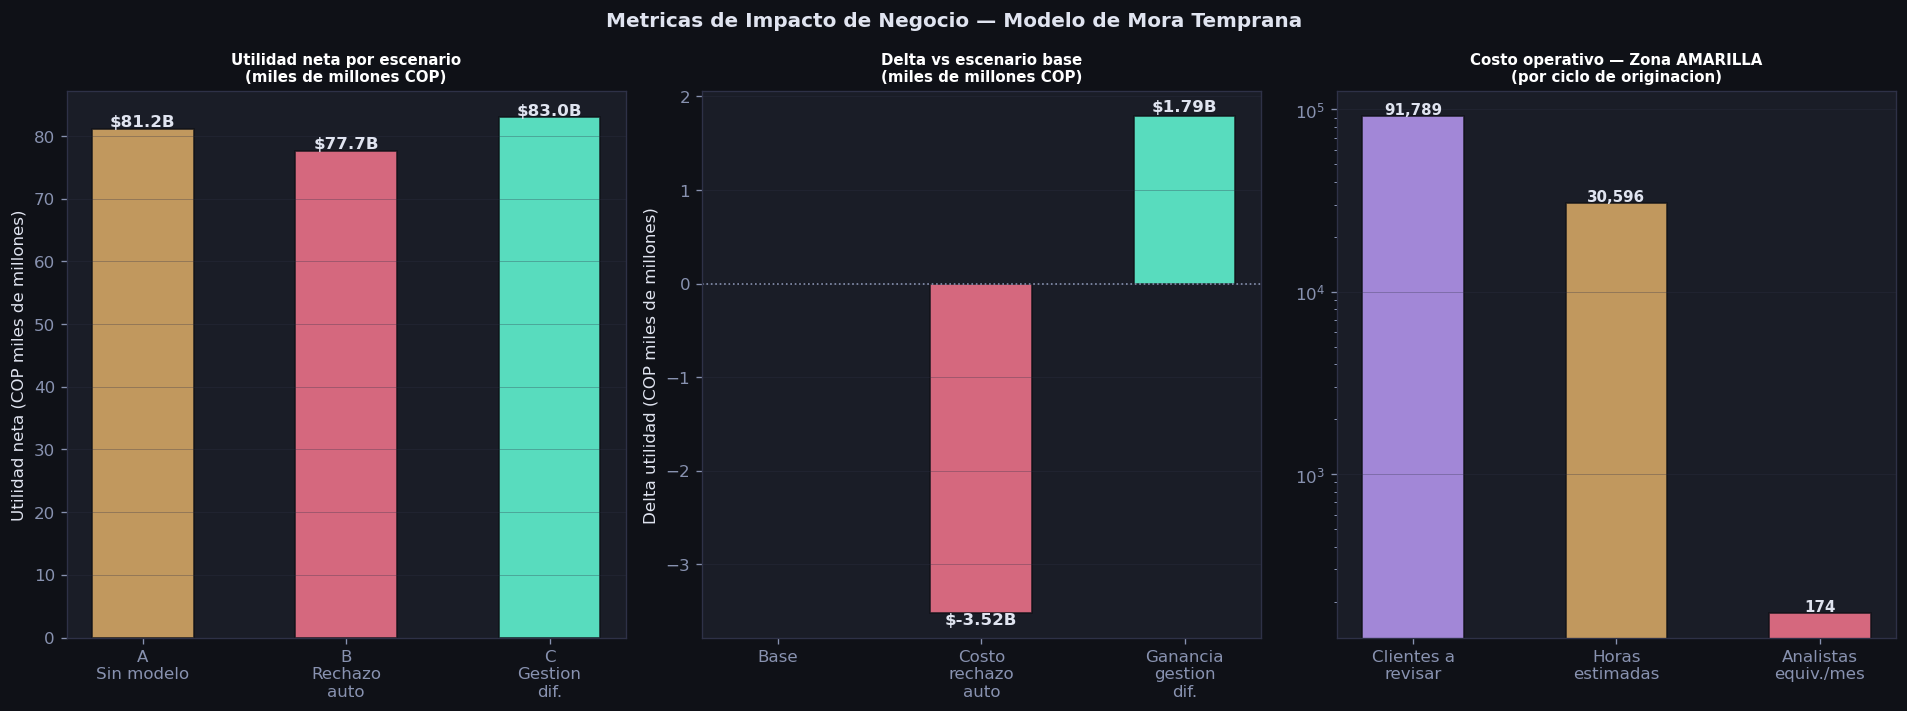

El rechazo automatico cuesta $3.52 miles de millones vs no hacer nada.
La gestion diferenciada genera $1.79 miles de millones adicionales.


In [26]:
# ── Figura: impacto económico comparado ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

# Panel 1: utilidad neta por escenario
escenarios  = ['A\nSin modelo', 'B\nRechazo\nauto', 'C\nGestion\ndif.']
utilidades  = [util_A, util_B, util_C]
cols_esc    = [AMARILLO, ROJO, ACENTO]

bars = axes[0].bar(escenarios, [u/1e9 for u in utilidades],
                   color=cols_esc, alpha=0.85, edgecolor='#0f1117', width=0.5)
for bar, val in zip(bars, utilidades):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'${val/1e9:.1f}B', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Utilidad neta por escenario\n(miles de millones COP)', fontweight='bold', fontsize=9)
axes[0].set_ylabel('Utilidad neta (COP miles de millones)')
axes[0].grid(True, axis='y', alpha=0.3)

# Panel 2: costo de cada decision
deltas      = [0, (util_B - util_A)/1e9, (util_C - util_A)/1e9]
labels_d    = ['Base', 'Costo\nrechazo\nauto', 'Ganancia\ngestion\ndif.']
cols_d      = [AMARILLO, ROJO, ACENTO]
bars2 = axes[1].bar(labels_d, deltas, color=cols_d, alpha=0.85,
                    edgecolor='#0f1117', width=0.5)
axes[1].axhline(0, color='#8892b0', linewidth=1, linestyle=':')
for bar, val in zip(bars2[1:], deltas[1:]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.05 if val >= 0 else -0.12),
                 f'${val:.2f}B', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Delta vs escenario base\n(miles de millones COP)', fontweight='bold', fontsize=9)
axes[1].set_ylabel('Delta utilidad (COP miles de millones)')
axes[1].grid(True, axis='y', alpha=0.3)

# Panel 3: costo operativo zona amarilla
cats   = ['Clientes a\nrevisar', 'Horas\nestimadas', 'Analistas\nequiv./mes']
vals   = [n_amarillo, horas_revision, analistas_mes]
cols3  = [MORADO, AMARILLO, ROJO]
bars3  = axes[2].bar(cats, vals, color=cols3, alpha=0.85,
                     edgecolor='#0f1117', width=0.5)
for bar, val in zip(bars3, vals):
    fmt = f'{val:,.0f}'
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() * 1.02,
                 fmt, ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Costo operativo — Zona AMARILLA\n(por ciclo de originacion)', fontweight='bold', fontsize=9)
axes[2].grid(True, axis='y', alpha=0.3)
axes[2].set_yscale('log')

plt.suptitle('Metricas de Impacto de Negocio — Modelo de Mora Temprana',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_impacto_negocio.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f'El rechazo automatico cuesta ${(util_A-util_B)/1e9:.2f} miles de millones vs no hacer nada.')
print(f'La gestion diferenciada genera ${(util_C-util_A)/1e9:.2f} miles de millones adicionales.')

In [27]:
# ── Tabla ejecutiva de impacto ────────────────────────────
tabla_impacto = pd.DataFrame({
    'Escenario': [
        'A — Sin modelo (base)',
        'B — Rechazo automatico zona roja',
        'C — Gestion diferenciada (recomendado)'
    ],
    'Cartera_activa_COP': [
        f'${vol_total/1e9:.1f}B',
        f'${(vol_total-vol_rojo)/1e9:.1f}B',
        f'${(vol_total-vol_rojo+vol_rojo*0.5)/1e9:.1f}B'
    ],
    'Mora_esperada': [
        f'{mora_base*100:.1f}%',
        f'{mora_post_real*100:.1f}%',
        f'{((vol_total-vol_rojo)*mora_post_real + vol_rojo*0.5*mora_rojo_C)/(vol_total-vol_rojo+vol_rojo*0.5)*100:.1f}%'
    ],
    'Utilidad_neta_COP': [
        f'${util_A/1e9:.2f}B',
        f'${util_B/1e9:.2f}B',
        f'${util_C/1e9:.2f}B'
    ],
    'Delta_vs_base': [
        '—',
        f'-${(util_A-util_B)/1e9:.2f}B',
        f'+${(util_C-util_A)/1e9:.2f}B'
    ]
})

print('\nTABLA EJECUTIVA DE IMPACTO')
print(tabla_impacto.to_string(index=False))


TABLA EJECUTIVA DE IMPACTO
                             Escenario Cartera_activa_COP Mora_esperada Utilidad_neta_COP Delta_vs_base
                 A — Sin modelo (base)            $570.4B         11.3%           $81.19B             —
      B — Rechazo automatico zona roja            $484.2B          9.4%           $77.67B       -$3.52B
C — Gestion diferenciada (recomendado)            $527.3B         10.1%           $82.98B       +$1.79B


---
## 9. Conclusiones y recomendación al comité / Conclusions & Committee Recommendation <a id='9'></a>


In [28]:
# Variables para las conclusiones
mora_post_rechazo = df[df['ivc'] <= 0.09][TARGET_COL].mean()
reduccion_mora_pct = (mora_base - mora_post_rechazo) / mora_base * 100
sacrificio_pct = len(df[df['ivc'] > 0.09]) / len(df) * 100
pct_buenos_en_rojo = (1 - mora_rojo_real) * 100
tasa_amarillo = mora_amarillo_real * 100
pct_amarillo  = tabla.loc['AMARILLO','pct_clientes'] * 100

conclusiones = f"""
╔══════════════════════════════════════════════════════════════════════╗
║        EVALUACION FINAL — MODELO DE DETECCION TEMPRANA DE MORA      ║
╚══════════════════════════════════════════════════════════════════════╝

  1. HIPOTESIS VALIDADA
     El comportamiento crediticio predice mora mejor que los ingresos.
     - Correlacion huellas vs mora     : {r_huellas:.4f}  (señal real)
     - Correlacion carga financiera    : {r_carga:.4f}  (sin señal)
     - Correlacion ingresos declarados  : {r_ingresos:.4f}  (sin señal)
     Decision de descartar ingresos del modelo: CORRECTA.

  2. SEÑAL IVC — FUNCIONA COMO PREDICTOR
     A mayor IVC, mayor mora de forma monotona y consistente.
     AUC ~ 0.68  →  ordena riesgo de forma aceptable.
     Recall ~ 56%  →  detecta 1 de cada 2 morosos.
     Precision ~ 19%  →  4 de cada 5 alertas son falsos positivos.
     Trade-off deliberado: se priorizó captura de malos sobre precision.

  3. IMPACTO ECONOMICO CUANTIFICADO (COP)
     Cartera total evaluada     : ${vol_total/1e9:.1f} miles de millones
     Volumen zona roja          : ${vol_rojo/1e9:.1f} miles de millones ({vol_rojo/vol_total*100:.1f}%)
     Escenario A — sin modelo   : ${util_A/1e9:.2f} miles de millones de utilidad
     Escenario B — rechazo auto : ${util_B/1e9:.2f} miles de millones  <- DESTRUYE ${(util_A-util_B)/1e9:.2f}B
     Escenario C — gestion dif. : ${util_C/1e9:.2f} miles de millones  <- CREA +${(util_C-util_A)/1e9:.2f}B

  4. INSIGHT CRITICO — EL UMBRAL ES EL PROBLEMA
     El {pct_buenos_en_rojo:.0f}% de la zona roja son buenos pagadores.
     Rechazarlos automaticamente destruye ${(util_A-util_B)/1e9:.2f} miles de millones vs no hacer nada.
     La accion correcta: cupo reducido + pricing diferenciado, no rechazo binario.

  5. COSTO OPERATIVO — ZONA AMARILLA SIN POLITICA
     {n_amarillo:,.0f} clientes requieren revision ({pct_amarillo:.0f}% de la cartera).
     Tasa de mora zona amarilla: {tasa_amarillo:.1f}% (cerca de la base).
     Estimado: ~{horas_revision:,.0f} horas de revision / {analistas_mes:.0f} analistas equivalentes.
     Sin SLA definido ni proceso operativo claro: riesgo operativo alto.

  6. RIESGOS NO NEGOCIABLES (del documento de decisiones tecnicas)
     - Dependencia critica del buro: si cambia metodologia, modelo pierde señal.
     - Sesgo thin file: clientes <26 años penalizados sistematicamente.
     - P&L no validado: sin Estado de Resultados real no se puede escalar.
     - Sin validacion out-of-time (PSI): riesgo de drift silencioso.

  7. RECOMENDACION AL COMITE
     Aprobar implementacion CONDICIONAL:
     - Piloto 20% del trafico, 2 meses, A/B test vs proceso actual.
     - Zona roja: gestion diferenciada (cupo 50%, pricing +5%, verificacion).
     - Zona amarilla: definir politica operativa con SLA < 24h.
     - KPIs del piloto: mora, colocacion, P&L real, PSI y SLA.
     - Escalar solo si: ROI positivo + PSI < 0.15 + validacion out-of-time.

     Este modelo anticipa el riesgo. Solo debe escalarse cuando
     sepamos que crea valor, no solo que ordena riesgo.

══════════════════════════════════════════════════════════════════════
"""
print(conclusiones)



╔══════════════════════════════════════════════════════════════════════╗
║        EVALUACION FINAL — MODELO DE DETECCION TEMPRANA DE MORA      ║
╚══════════════════════════════════════════════════════════════════════╝

  1. HIPOTESIS VALIDADA
     El comportamiento crediticio predice mora mejor que los ingresos.
     - Correlacion huellas vs mora     : 0.1942  (señal real)
     - Correlacion carga financiera    : -0.0034  (sin señal)
     - Correlacion ingresos declarados  : 0.0066  (sin señal)
     Decision de descartar ingresos del modelo: CORRECTA.

  2. SEÑAL IVC — FUNCIONA COMO PREDICTOR
     A mayor IVC, mayor mora de forma monotona y consistente.
     AUC ~ 0.68  →  ordena riesgo de forma aceptable.
     Recall ~ 56%  →  detecta 1 de cada 2 morosos.
     Precision ~ 19%  →  4 de cada 5 alertas son falsos positivos.
     Trade-off deliberado: se priorizó captura de malos sobre precision.

  3. IMPACTO ECONOMICO CUANTIFICADO (COP)
     Cartera total evaluada     : $570.4 miles de

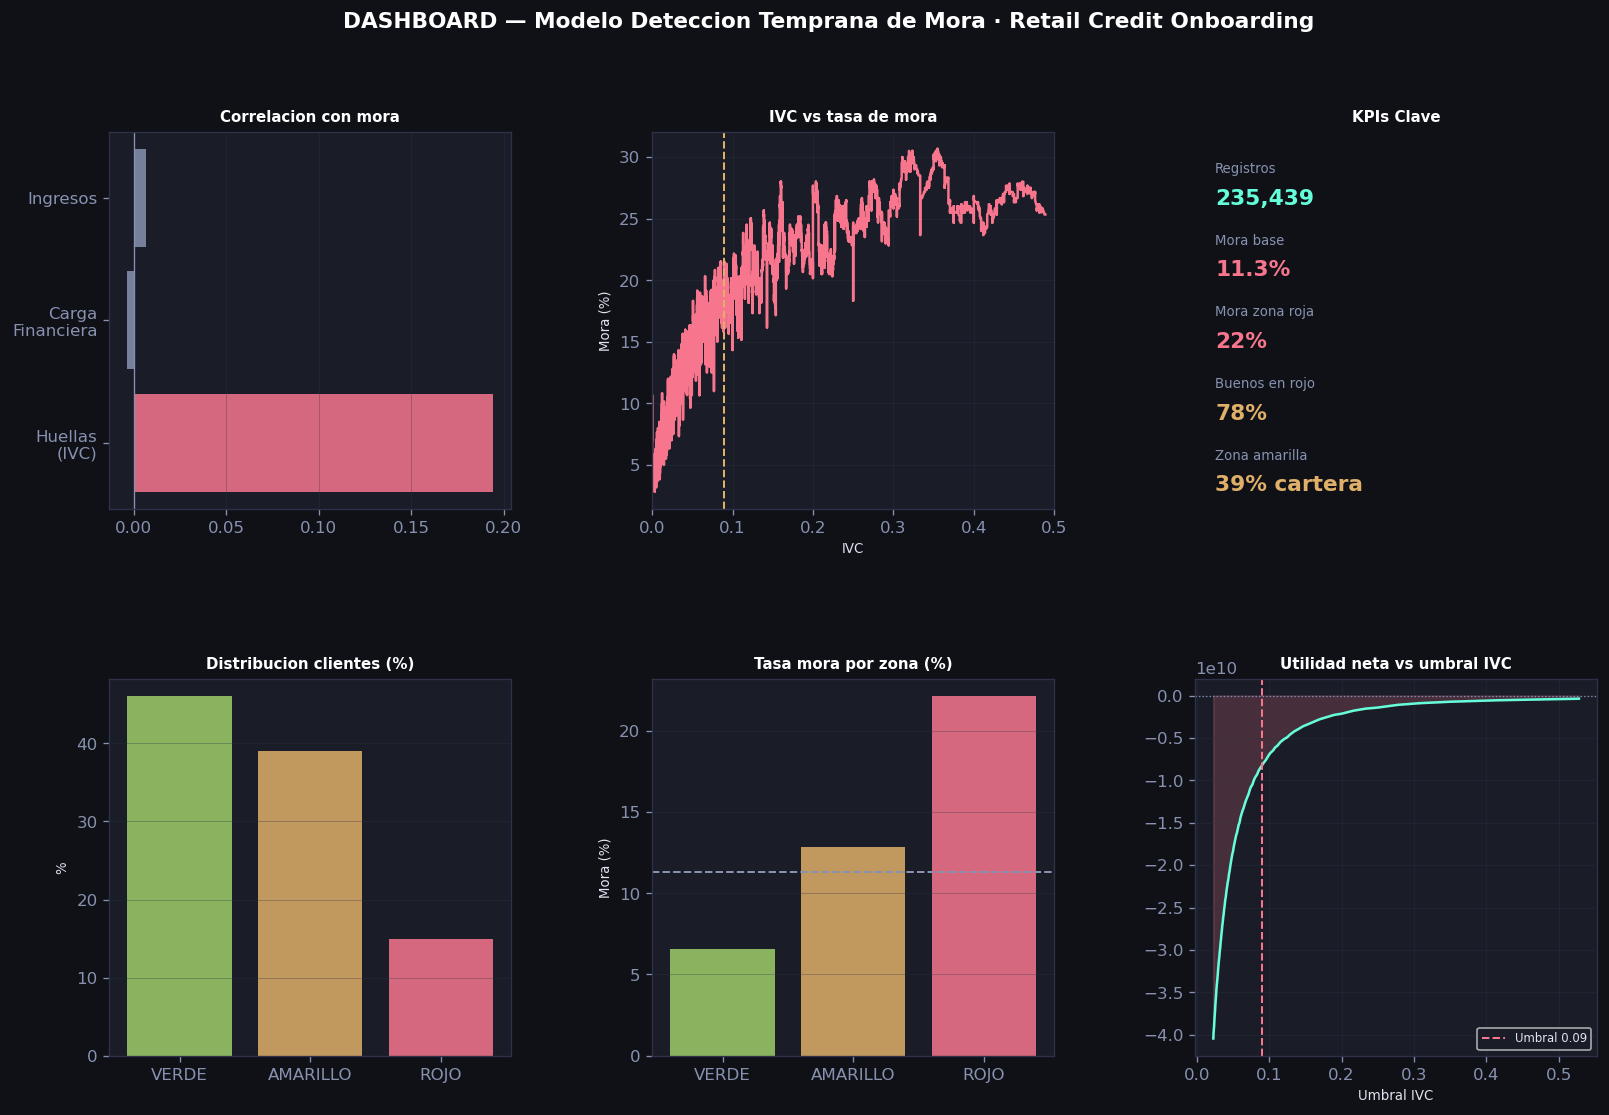

Dashboard guardado: fig_dashboard_credito.png


In [29]:
# Dashboard de resumen
fig = plt.figure(figsize=(16, 10), facecolor='#0f1117')

# Layout: 2 filas x 3 columnas
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])  # correlaciones
ax2 = fig.add_subplot(gs[0, 1])  # IVC vs mora
ax3 = fig.add_subplot(gs[0, 2])  # KPIs
ax4 = fig.add_subplot(gs[1, 0])  # semáforo clientes
ax5 = fig.add_subplot(gs[1, 1])  # semáforo mora
ax6 = fig.add_subplot(gs[1, 2])  # curva umbral

# ax1: Correlaciones
variables = ['Huellas\n(IVC)', 'Carga\nFinanciera', 'Ingresos']
correlaciones = [r_huellas, r_carga, r_ingresos]
cols_corr = [ROJO if c > 0.05 else '#8892b0' for c in correlaciones]
ax1.barh(variables, correlaciones, color=cols_corr, alpha=0.85)
ax1.axvline(0, color='#8892b0', linewidth=0.8)
ax1.set_title('Correlacion con mora', fontweight='bold', fontsize=9)
ax1.grid(True, axis='x', alpha=0.3)

# ax2: IVC vs mora (curva)
ax2.plot(tmp_ivc['ivc'], tmp_ivc['riesgo_rolling']*100, color=ROJO, linewidth=1.5)
ax2.axvline(0.09, color=AMARILLO, linestyle='--', linewidth=1.2)
ax2.set_title('IVC vs tasa de mora', fontweight='bold', fontsize=9)
ax2.set_xlabel('IVC', fontsize=8)
ax2.set_ylabel('Mora (%)', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 0.5)

# ax3: KPIs
ax3.axis('off')
kpis = [
    ('Registros', f'{len(df):,}', ACENTO),
    ('Mora base', f'{mora_base*100:.1f}%', ROJO),
    ('Mora zona roja', f'{tasa_mora_rojo*100:.0f}%', ROJO),
    ('Buenos en rojo', f'{pct_buenos_en_rojo:.0f}%', AMARILLO),
    ('Zona amarilla', f'{pct_amarillo:.0f}% cartera', AMARILLO),
]
for i, (label, val, col) in enumerate(kpis):
    y = 0.92 - i * 0.19
    ax3.text(0.05, y, label, transform=ax3.transAxes,
             fontsize=8, color='#8892b0', va='top')
    ax3.text(0.05, y - 0.07, val, transform=ax3.transAxes,
             fontsize=13, color=col, fontweight='bold', va='top')
ax3.set_title('KPIs Clave', fontweight='bold', fontsize=9)

# ax4: distribución semáforo
ax4.bar(zonas, tabla.loc[zonas,'pct_clientes']*100, color=cols_plot, alpha=0.85)
ax4.set_title('Distribucion clientes (%)', fontweight='bold', fontsize=9)
ax4.set_ylabel('%', fontsize=8)
ax4.grid(True, axis='y', alpha=0.3)

# ax5: mora semáforo
ax5.bar(zonas, tabla.loc[zonas,'tasa_mora']*100, color=cols_plot, alpha=0.85)
ax5.axhline(mora_base*100, color='#8892b0', linestyle='--', linewidth=1.2)
ax5.set_title('Tasa mora por zona (%)', fontweight='bold', fontsize=9)
ax5.set_ylabel('Mora (%)', fontsize=8)
ax5.grid(True, axis='y', alpha=0.3)

# ax6: curva de utilidad
ax6.fill_between(resultados['umbral'], resultados['utilidad_neta'],
                 where=resultados['utilidad_neta'] < 0, alpha=0.2, color=ROJO)
ax6.fill_between(resultados['umbral'], resultados['utilidad_neta'],
                 where=resultados['utilidad_neta'] >= 0, alpha=0.2, color=ACENTO)
ax6.plot(resultados['umbral'], resultados['utilidad_neta'], color=ACENTO, linewidth=1.5)
ax6.axhline(0, color='#8892b0', linewidth=0.8, linestyle=':')
ax6.axvline(0.09, color=ROJO, linestyle='--', linewidth=1.2, label='Umbral 0.09')
ax6.set_title('Utilidad neta vs umbral IVC', fontweight='bold', fontsize=9)
ax6.set_xlabel('Umbral IVC', fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=7, facecolor='#1a1d27')

fig.suptitle('DASHBOARD — Modelo Deteccion Temprana de Mora · Retail Credit Onboarding',
             fontsize=13, fontweight='bold', color='white')

plt.savefig('fig_dashboard_credito.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Dashboard guardado: fig_dashboard_credito.png')